# India Job Market Analysis — Data Science & Data Analytics

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('raw_job_data.csv')

print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset loaded successfully!
Shape: 19,229 rows x 12 columns


,Job Titles,Company Names,Experience Required,Package,Locations,Skills,Role Type,Primary Location,Exp Min,Exp Max,Exp Category,Salary Disclosed
0,Manager - Digital Product Analytics [Data Scie...,Resy,4-8 Yrs,Not disclosed,Gurgaon/Gurugram,Product managementCareer developmentOperations...,Data Science,Gurgaon,4,8,Mid Level (3-5 Yrs),Not Disclosed
1,Data Science Domain Manager,Coursera,7-11 Yrs,Not disclosed,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunder...",Computer scienceContent strategyData analysisU...,Data Science,Kolkata,7,11,Senior (6-10 Yrs),Not Disclosed
2,GN - Strategy - MC - T&O - NLP Data Science - ...,Accenture,1-3 Yrs,Not disclosed,"Mumbai, Hyderabad/Secunderabad, Pune, Gurgaon/...",Change managementSASCodingData miningPythonRst...,Data Science,Mumbai,1,3,Junior (1-2 Yrs),Not Disclosed
3,Data Science Manager,Foreign IT Consulting MNC,2-6 Yrs,Not disclosed,Gurgaon/Gurugram,Operations researchSASFinanceProject managemen...,Data Science,Gurgaon,2,6,Junior (1-2 Yrs),Not Disclosed
4,Data Science Manager,Foreign IT Consulting MNC,3-6 Yrs,Not disclosed,Noida,Data analysisEDCRisk assessmentrisk modelingMa...,Data Science,Noida,3,6,Mid Level (3-5 Yrs),Not Disclosed


## 3. First Look at the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19229 entries, 0 to 19228
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Job Titles           19229 non-null  object
 1   Company Names        19229 non-null  object
 2   Experience Required  19229 non-null  object
 3   Package              19229 non-null  object
 4   Locations            19229 non-null  object
 5   Skills               19229 non-null  object
 6   Role Type            19229 non-null  object
 7   Primary Location     19229 non-null  object
 8   Exp Min              19229 non-null  int64 
 9   Exp Max              19229 non-null  int64 
 10  Exp Category         19229 non-null  object
 11  Salary Disclosed     19229 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.8+ MB


## 4. Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

                     Missing Count  Missing %
Job Titles                       0        0.0
Company Names                    0        0.0
Experience Required              0        0.0
Package                          0        0.0
Locations                        0        0.0
Skills                           0        0.0
Role Type                        0        0.0
Primary Location                 0        0.0
Exp Min                          0        0.0
Exp Max                          0        0.0
Exp Category                     0        0.0
Salary Disclosed                 0        0.0


## 5. Drop Nulls in Key Columns

In [5]:
df.dropna(subset=['Job Titles', 'Company Names', 'Experience Required', 'Skills', 'Locations'], inplace=True)
print(f'After dropping null rows: {df.shape[0]:,} rows')

After dropping null rows: 19,229 rows


## 6. Duplicate Check and Drop

In [6]:
print(f'Duplicate rows: {df.duplicated().sum():,}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'After dropping duplicates: {df.shape[0]:,} rows')
print('Index reset done!')

Duplicate rows: 0
After dropping duplicates: 19,229 rows
Index reset done!


## 7. Extract Role Type from Job Title

In [7]:
def extract_role(title):
    title = str(title).lower()
    if 'data science' in title or 'data scientist' in title:
        return 'Data Science'
    elif 'analyst' in title or 'analytics' in title:
        return 'Data Analytics'
    else:
        return 'Other'

df['Role Type'] = df['Job Titles'].apply(extract_role)
print('Role Type column created!')
print(df['Role Type'].value_counts())

Role Type column created!
Role Type
Data Analytics    9810
Other             7149
Data Science      2270
Name: count, dtype: int64


## 8. Clean Locations

In [8]:
def clean_location(loc):
    if pd.isna(loc):
        return 'Unknown'
    city = str(loc).split(',')[0].strip()
    city = city.replace('Bangalore/Bengaluru', 'Bangalore')
    city = city.replace('Bengaluru', 'Bangalore')
    city = city.replace('Gurgaon/Gurugram', 'Gurgaon')
    city = city.replace('Gurugram', 'Gurgaon')
    city = city.replace('Hyderabad/Secunderabad', 'Hyderabad')
    city = city.replace('New Delhi', 'Delhi')
    return city

df['Primary Location'] = df['Locations'].apply(clean_location)
print('Primary Location column created!')
print(df['Primary Location'].value_counts().head(10))

Primary Location column created!
Primary Location
Bangalore    4165
Hyderabad    1942
Mumbai       1726
Gurgaon      1422
Pune         1322
Kolkata      1066
Remote       1020
Chennai       963
Noida         930
Delhi         698
Name: count, dtype: int64


## 9. Clean Experience

In [9]:
def extract_exp_min(exp):
    try:
        return int(str(exp).split('-')[0].strip())
    except:
        return np.nan

def extract_exp_max(exp):
    try:
        return int(str(exp).split('-')[1].replace('Yrs','').strip())
    except:
        return np.nan

def categorize_exp(min_exp):
    if pd.isna(min_exp):
        return 'Unknown'
    elif min_exp == 0:
        return 'Fresher (0 Yrs)'
    elif min_exp <= 2:
        return 'Junior (1-2 Yrs)'
    elif min_exp <= 5:
        return 'Mid Level (3-5 Yrs)'
    elif min_exp <= 10:
        return 'Senior (6-10 Yrs)'
    else:
        return 'Expert (10+ Yrs)'

df['Exp Min'] = df['Experience Required'].apply(extract_exp_min)
df['Exp Max'] = df['Experience Required'].apply(extract_exp_max)
df['Exp Category'] = df['Exp Min'].apply(categorize_exp)

print('Experience columns created!')
print(df['Exp Category'].value_counts())

Experience columns created!
Exp Category
Mid Level (3-5 Yrs)    8194
Junior (1-2 Yrs)       5991
Senior (6-10 Yrs)      3253
Fresher (0 Yrs)        1426
Expert (10+ Yrs)        365
Name: count, dtype: int64


## 10. Clean Package / Salary

In [10]:
df['Salary Disclosed'] = df['Package'].apply(
    lambda x: 'Disclosed' if str(x).lower() != 'not disclosed' and pd.notna(x) else 'Not Disclosed'
)
print('Salary Disclosed column created!')
print(df['Salary Disclosed'].value_counts())

Salary Disclosed column created!
Salary Disclosed
Not Disclosed    17511
Disclosed         1718
Name: count, dtype: int64


## 11. Final Cleaned Dataset Overview

In [11]:
print('Final Cleaned Dataset:')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
df.head()

Final Cleaned Dataset:
Rows: 19,229
Columns: 12



,Job Titles,Company Names,Experience Required,Package,Locations,Skills,Role Type,Primary Location,Exp Min,Exp Max,Exp Category,Salary Disclosed
0,Manager - Digital Product Analytics [Data Scie...,Resy,4-8 Yrs,Not disclosed,Gurgaon/Gurugram,Product managementCareer developmentOperations...,Data Science,Gurgaon,4,8,Mid Level (3-5 Yrs),Not Disclosed
1,Data Science Domain Manager,Coursera,7-11 Yrs,Not disclosed,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunder...",Computer scienceContent strategyData analysisU...,Data Science,Kolkata,7,11,Senior (6-10 Yrs),Not Disclosed
2,GN - Strategy - MC - T&O - NLP Data Science - ...,Accenture,1-3 Yrs,Not disclosed,"Mumbai, Hyderabad/Secunderabad, Pune, Gurgaon/...",Change managementSASCodingData miningPythonRst...,Data Science,Mumbai,1,3,Junior (1-2 Yrs),Not Disclosed
3,Data Science Manager,Foreign IT Consulting MNC,2-6 Yrs,Not disclosed,Gurgaon/Gurugram,Operations researchSASFinanceProject managemen...,Data Science,Gurgaon,2,6,Junior (1-2 Yrs),Not Disclosed
4,Data Science Manager,Foreign IT Consulting MNC,3-6 Yrs,Not disclosed,Noida,Data analysisEDCRisk assessmentrisk modelingMa...,Data Science,Noida,3,6,Mid Level (3-5 Yrs),Not Disclosed


## 12. Save Cleaned Dataset

In [12]:
df.to_csv('jobs_clean.csv', index=False)
print('Cleaned dataset saved as jobs_clean.csv!')

Cleaned dataset saved as jobs_clean.csv!


## 13. Skills Preprocessing — Exploded Skills Table


In [13]:

skill_normalize = {
    # Data Analysis variants
    'analytical':            'Data Analysis',
    'analytics':             'Data Analysis',
    'data analytics':        'Data Analysis',
    'data analysis':         'Data Analysis',

    # Business Analyst / Business Analysis 
    'business analyst':      None,
    'business analysis':     'Business Analysis',
    'business analytics':    'Business Analysis',

    # Machine Learning variants
    'machine learning':      'Machine Learning',
    'ml':                    'Machine Learning',

    # Project Management variants
    'project management':    'Project Management',
    'project manager':       None,   

    # Agile variants
    'agile':                 'Agile',
    'agile methodology':     'Agile',
    'agile methodologies':   'Agile',

    # Deep Learning variants
    'deep learning':         'Deep Learning',
    'dl':                    'Deep Learning',

    # NLP variants
    'natural language processing': 'NLP',
    'nlp':                   'NLP',

    # Power BI variants
    'power bi':              'Power BI',
    'powerbi':               'Power BI',

    # Communication variants
    'communication':         'Communication',
    'communication skills':  'Communication',

    # Scikit variants
    'scikit':                'Scikit-learn',
    'scikit-learn':          'Scikit-learn',
    'sklearn':               'Scikit-learn',
}

drop_skills = {
    'data',         
    'science',     
    'learning',
    'management',
    'analysis',     
    'analyst',
    'engineer',      
    'developer',    
    'manager',      
    'business analyst',
    'data analyst',
    'data scientist',
    'a',            
    'the',           
    'of',           
}

def split_camel(s):
    """Split CamelCase-concatenated skill strings into individual skills."""
    s = re.sub(r'([a-z])([A-Z])', r'\1,\2', str(s))
    return [x.strip() for x in s.split(',') if x.strip()]

rows = []
for _, row in df.iterrows():
    skills = split_camel(row['Skills'])
    for skill in skills:
        skill_lower = skill.lower().strip()

        if skill_lower in drop_skills:
            continue

        
        if len(skill_lower) <= 2:
            continue

        normalized = skill_normalize.get(skill_lower, skill)

        if normalized is None:
            continue

        rows.append({
            'skill':            normalized,
            'role_type':        row['Role Type'],
            'exp_category':     row['Exp Category'],
            'primary_location': row['Primary Location']
        })

skills_exploded = pd.DataFrame(rows)

print(f'Total skill mentions: {len(skills_exploded):,}')
print(f'Unique skills found: {skills_exploded["skill"].nunique():,}')
print()
print('Top 20 skills:')
print(skills_exploded['skill'].value_counts().head(20))


Total skill mentions: 117,626
Unique skills found: 15,166

Top 20 skills:
skill
Data Analysis            9965
Machine Learning         2091
Business Analysis        2024
Agile                    1530
Project Management       1302
Automation               1004
Computer science          976
Excel                     955
Data management           932
SQL                       884
Consulting                869
Data quality              819
Data modeling             799
Python                    797
Business intelligence     785
Data mining               741
Healthcare                738
Manager Technology        654
Coding                    646
Operations                618
Name: count, dtype: int64


## 14. Save Exploded Skills Table

In [14]:
skills_exploded.to_csv('skills_exploded.csv', index=False)
print('skills_exploded.csv saved!')
print('Load this file as a separate table in Power BI for the skills visuals.')

skills_exploded.csv saved!
Load this file as a separate table in Power BI for the skills visuals.


---
## 17. EDA — Role Type Distribution

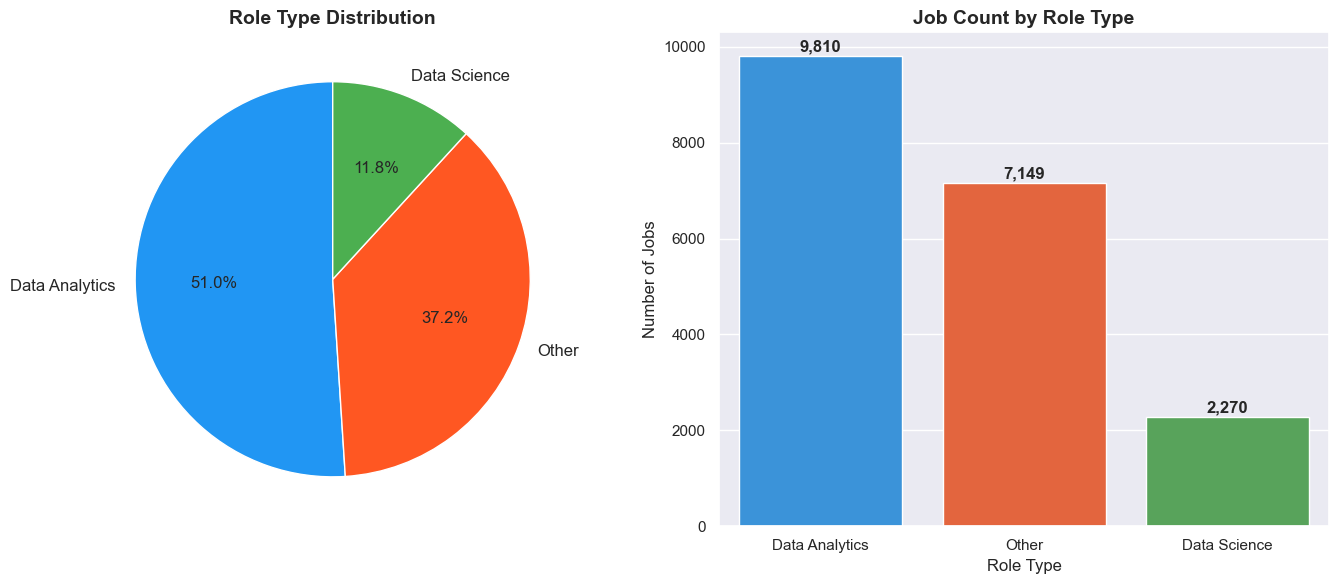

Saved: plot_01_role_distribution.png


In [15]:
role_counts = df['Role Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2196F3', '#FF5722', '#4CAF50']
axes[0].pie(role_counts, labels=role_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Role Type Distribution', fontsize=14, fontweight='bold')

sns.barplot(x=role_counts.index, y=role_counts.values, palette=colors, ax=axes[1])
axes[1].set_title('Job Count by Role Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Role Type')
axes[1].set_ylabel('Number of Jobs')
for i, v in enumerate(role_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_01_role_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_01_role_distribution.png')

## 18. EDA — Top 15 Cities by Job Openings

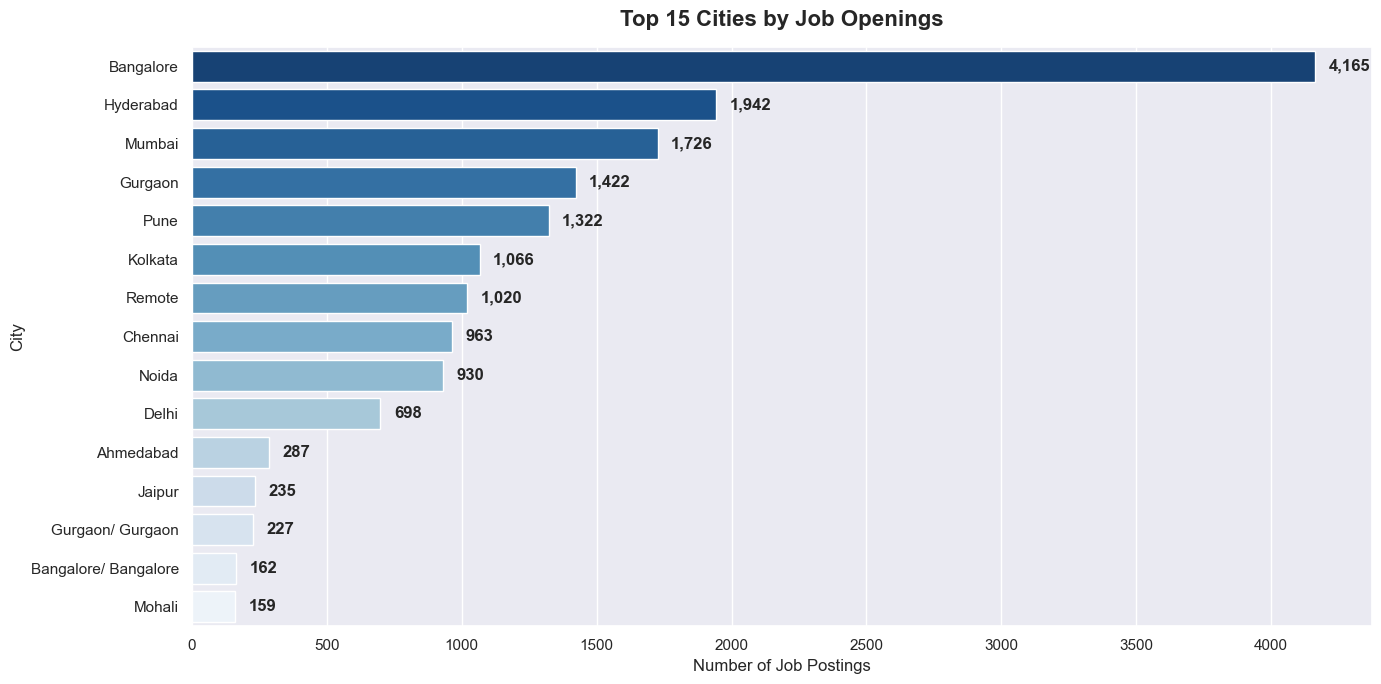

Saved: plot_02_top_cities.png


In [16]:
top_cities = df['Primary Location'].value_counts().head(15)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')

for i, v in enumerate(top_cities.values):
    plt.text(v + 50, i, f'{v:,}', va='center', fontweight='bold')

plt.title('Top 15 Cities by Job Openings', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('plot_02_top_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_02_top_cities.png')

## 20. EDA — Experience Level Distribution

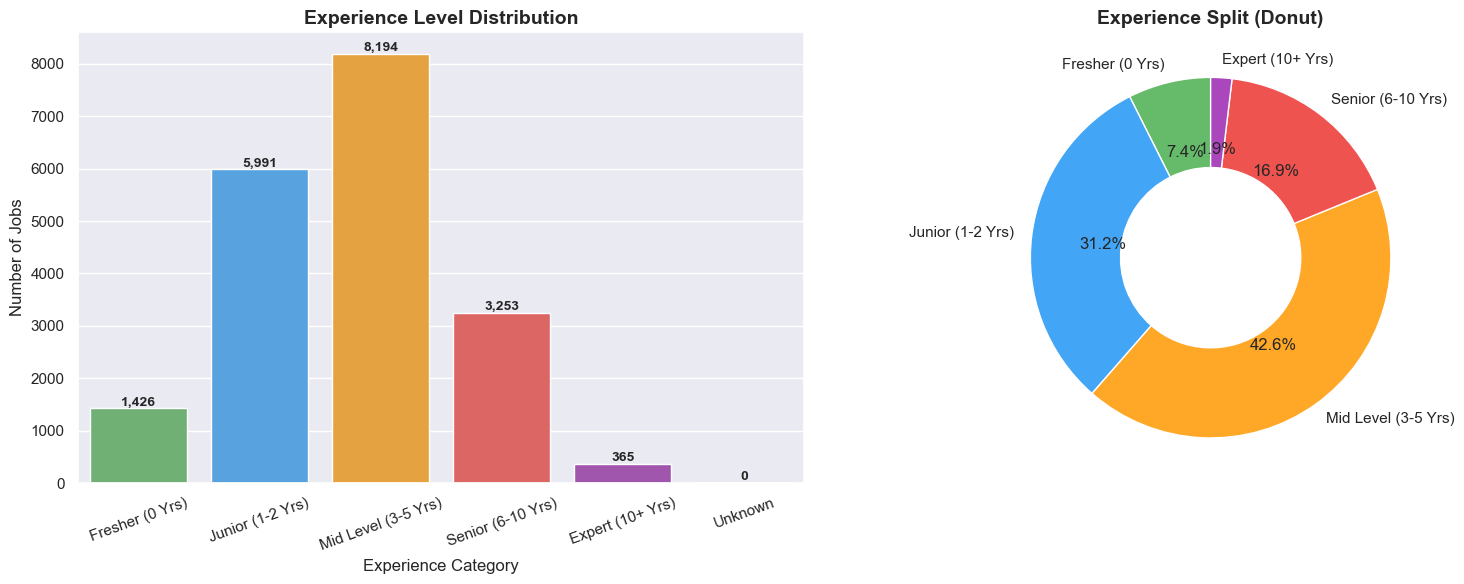

Saved: plot_04_experience.png


In [18]:
exp_order = ['Fresher (0 Yrs)', 'Junior (1-2 Yrs)', 'Mid Level (3-5 Yrs)',
             'Senior (6-10 Yrs)', 'Expert (10+ Yrs)', 'Unknown']

exp_counts = df['Exp Category'].value_counts().reindex(exp_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_exp = ['#66BB6A', '#42A5F5', '#FFA726', '#EF5350', '#AB47BC', '#78909C']
sns.barplot(x=exp_counts.index, y=exp_counts.values, palette=colors_exp, ax=axes[0])
axes[0].set_title('Experience Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Experience Category')
axes[0].set_ylabel('Number of Jobs')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(exp_counts.values):
    axes[0].text(i, v + 50, f'{int(v):,}', ha='center', fontweight='bold', fontsize=10)

filtered = exp_counts[exp_counts > 0]
axes[1].pie(filtered, labels=filtered.index, autopct='%1.1f%%',
            colors=colors_exp[:len(filtered)], startangle=90,
            wedgeprops=dict(width=0.5))
axes[1].set_title('Experience Split (Donut)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_04_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_04_experience.png')

## 21. EDA — Top 15 Hiring Companies

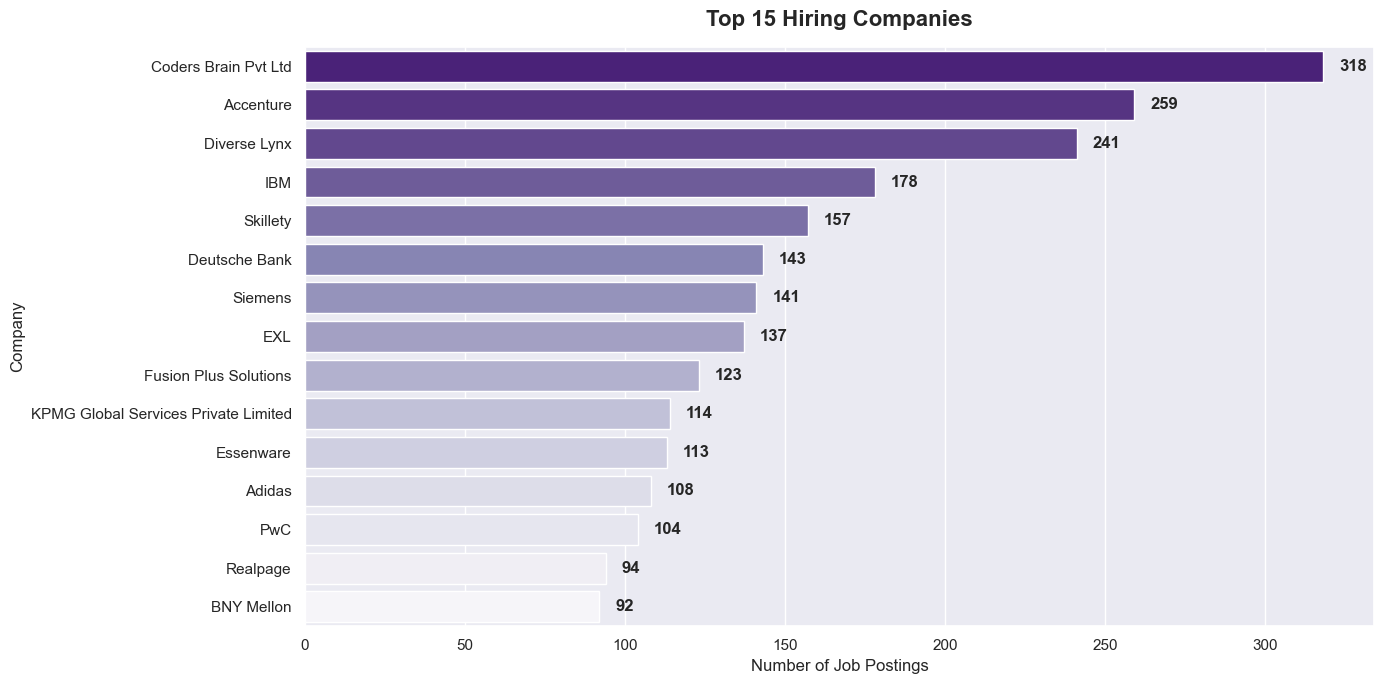

Saved: plot_05_top_companies.png


In [19]:
top_companies = df['Company Names'].value_counts().head(15)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='Purples_r')

for i, v in enumerate(top_companies.values):
    plt.text(v + 5, i, f'{v:,}', va='center', fontweight='bold')

plt.title('Top 15 Hiring Companies', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('Company')
plt.tight_layout()
plt.savefig('plot_05_top_companies.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_05_top_companies.png')

## 23. EDA — Experience Distribution by Role Type

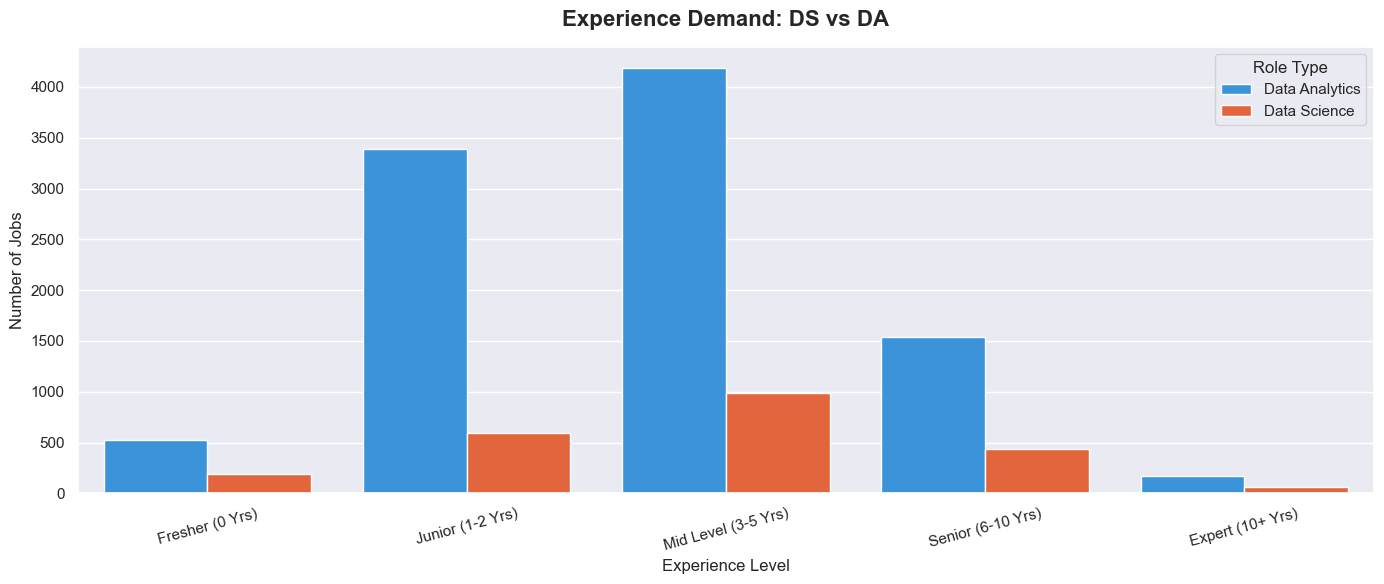

Saved: plot_07_exp_by_role.png


In [21]:
exp_role = df[df['Role Type'].isin(['Data Science', 'Data Analytics'])]\
             .groupby(['Role Type', 'Exp Category']).size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=exp_role, x='Exp Category', y='Count',
            hue='Role Type', palette=['#2196F3', '#FF5722'],
            order=exp_order[:-1])

plt.title('Experience Demand: DS vs DA', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Experience Level')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=15)
plt.legend(title='Role Type')
plt.tight_layout()
plt.savefig('plot_07_exp_by_role.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_07_exp_by_role.png')

## 24. EDA — Top Cities per Role Type

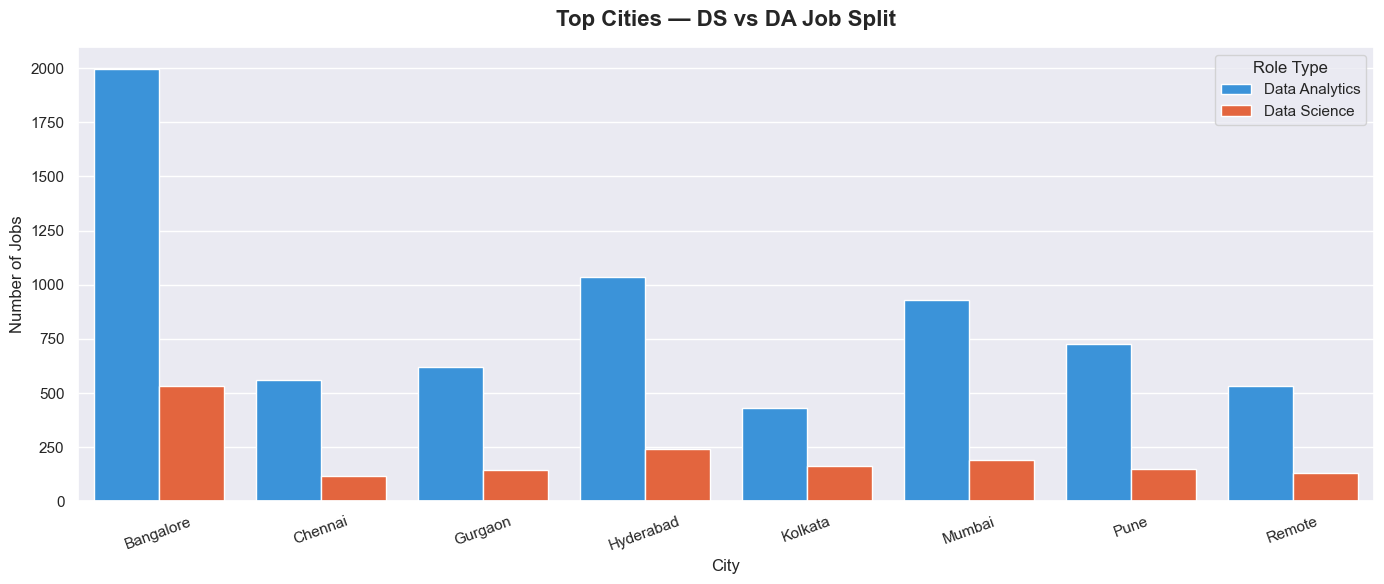

Saved: plot_08_cities_by_role.png


In [22]:
top_cities_list = df['Primary Location'].value_counts().head(8).index.tolist()

city_role = df[
    (df['Role Type'].isin(['Data Science', 'Data Analytics'])) &
    (df['Primary Location'].isin(top_cities_list))
].groupby(['Primary Location', 'Role Type']).size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=city_role, x='Primary Location', y='Count',
            hue='Role Type', palette=['#2196F3', '#FF5722'])

plt.title('Top Cities — DS vs DA Job Split', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('City')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=20)
plt.legend(title='Role Type')
plt.tight_layout()
plt.savefig('plot_08_cities_by_role.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_08_cities_by_role.png')

---
## 26. Connect to PostgreSQL



In [ ]:
import os
from sqlalchemy import create_engine

username = os.environ.get('PG_USER', 'postgres')
password = os.environ.get('PG_PASSWORD', '')
host = os.environ.get('PG_HOST', 'localhost')
port = os.environ.get('PG_PORT', '5432')
database = os.environ.get('PG_DB', 'Job_market_db')

engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

df.to_sql('jobs', engine, if_exists='replace', index=False)
print(f'Data loaded into PostgreSQL table: jobs')